In [45]:
# Quick fix for file paths - check what results files are actually available
import os
import numpy as np  # Add missing import
print("🔍 Available classification results:")
results_files = os.listdir('../results/')
classification_files = [f for f in results_files if any(keyword in f.lower() for keyword in ['diag', 'confusion', 'cv', 'cm'])]
for f in classification_files:
    print(f"  ✓ {f}")
print()

🔍 Available classification results:
  ✓ acdc_diag_cm_geom.csv
  ✓ acdc_diag_cv_metrics_geom.csv



# Cardiac Disease Classification Report

This notebook analyzes the performance of cardiac disease classification models using geometric features extracted from ACDC segmentations.

## Overview
- **Dataset**: ACDC (Automated Cardiac Diagnosis Challenge)
- **Task**: Multi-class classification of cardiac conditions
- **Classes**: DCM, HCM, MINF, NOR, RV (5 classes, 20 patients each)
- **Features**: LV volumes, EF, myocardial thickness, geometric measures
- **Model**: HistGradientBoostingClassifier with 5-fold GroupKFold CV

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Explore Data

In [47]:
# Load feature data and labels
features_df = pd.read_csv('../results/acdc_oof_features_geom.csv')
labels_df = pd.read_csv('../results/acdc_labels.csv')

# Merge features with labels
df = features_df.merge(labels_df, on='patient_id', how='inner')

print(f"Dataset shape: {df.shape}")
print(f"\nDiagnosis distribution:")
print(df['diagnosis'].value_counts())

print(f"\nFeature columns:")
feature_cols = [col for col in df.columns if col not in ['patient_id', 'diagnosis', 'study_id_ED', 'study_id_ES']]
for i, col in enumerate(feature_cols, 1):
    print(f"{i:2d}. {col}")

Dataset shape: (100, 22)

Diagnosis distribution:
diagnosis
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64

Feature columns:
 1. RVEDV_ml
 2. RVESV_ml
 3. RVEF_pct_robust
 4. LVEDV_ml
 5. LVESV_ml
 6. LVEF_pct_robust
 7. MYO_ED_ml
 8. MYO_ES_ml
 9. MYO_ES_to_ED_ratio
10. MYO_th_mean_ED_mm
11. MYO_th_p95_ED_mm
12. MYO_th_max_ED_mm
13. MYO_th_mean_ES_mm
14. MYO_th_p95_ES_mm
15. MYO_th_max_ES_mm
16. MYO_th_ratio_ES_ED
17. LV_axis23_ED
18. LV_axis13_ED


## 2. Feature Analysis

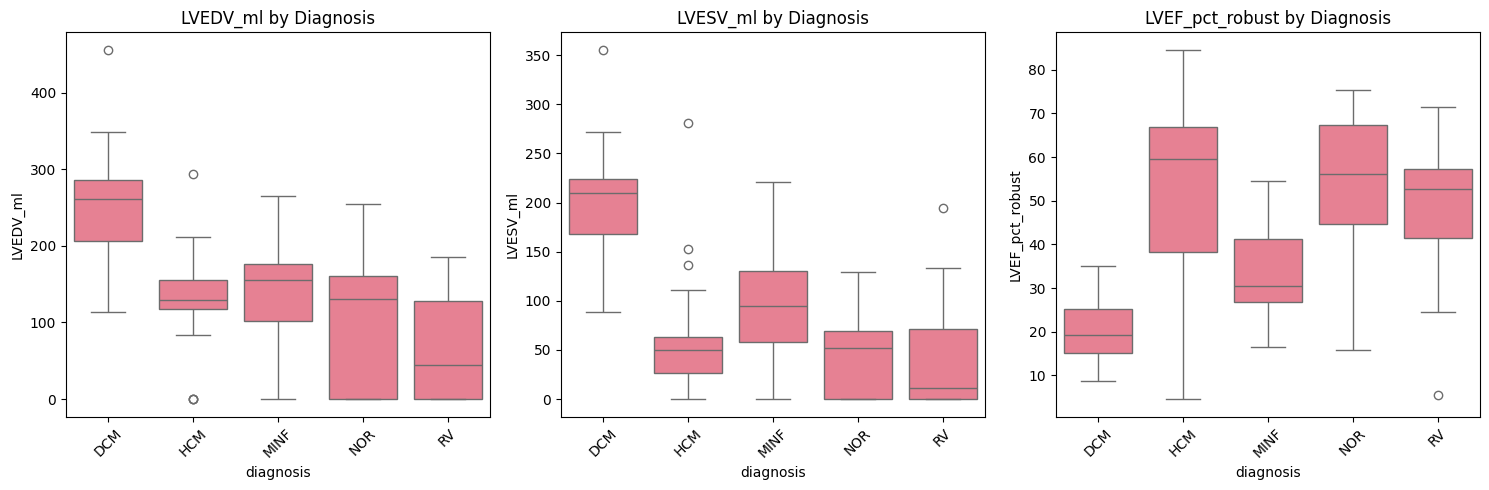


LV Feature Summary by Diagnosis:


LVEDV_ml        LVESV_ml        LVEF_pct_robust       
              mean    std     mean    std            mean    std
diagnosis                                                       
DCM         250.24  79.77   200.74  59.72           20.53   7.49
HCM         125.91  69.13    62.53  66.21           50.84  26.70
MINF        137.23  75.82    96.40  60.28           33.13  10.43
NOR         107.83  79.23    48.74  39.93           54.14  16.42
RV           65.77  69.67    38.65  53.16           46.21  19.96

In [48]:
# Analyze LV features by diagnosis
lv_features = ['LVEDV_ml', 'LVESV_ml', 'LVEF_pct_robust']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(lv_features):
    sns.boxplot(data=df, x='diagnosis', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature} by Diagnosis')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/lv_features_by_diagnosis.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nLV Feature Summary by Diagnosis:")
summary = df.groupby('diagnosis')[lv_features].agg(['mean', 'std']).round(2)
display(summary)

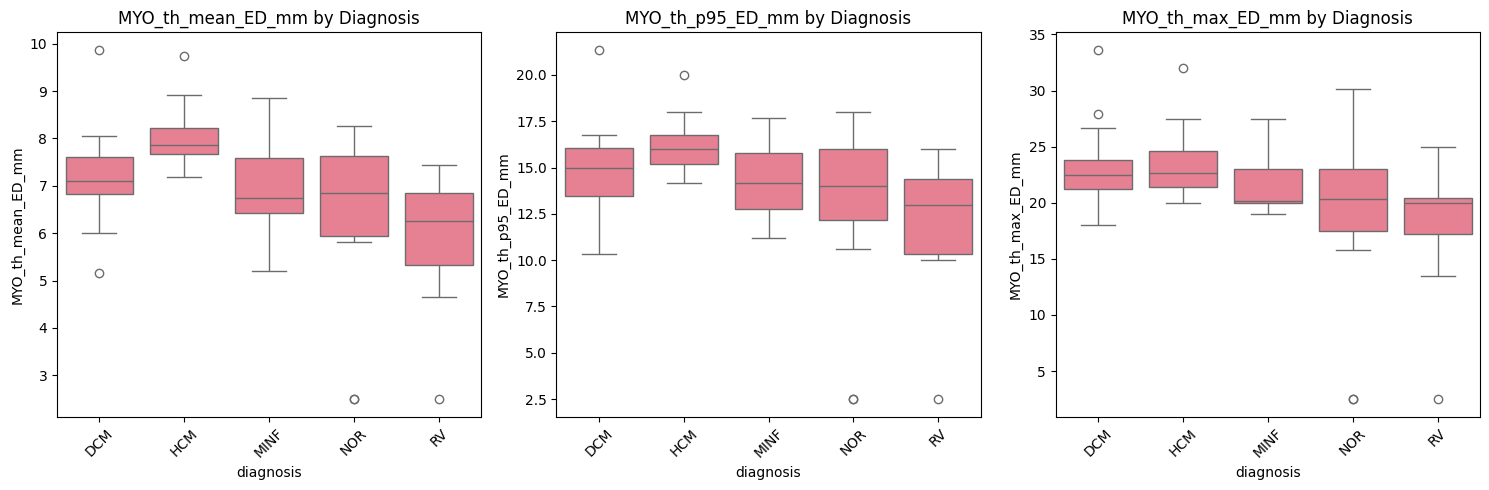


Myocardial Thickness Summary by Diagnosis:


MYO_th_mean_ED_mm       MYO_th_p95_ED_mm       MYO_th_max_ED_mm  \
                       mean   std             mean   std             mean   
diagnosis                                                                   
DCM                    7.19  0.95            14.88  2.29            23.10   
HCM                    8.01  0.63            16.30  1.49            23.48   
MINF                   6.94  1.01            14.36  2.14            21.56   
NOR                    6.48  1.77            12.98  4.65            19.09   
RV                     5.95  1.40            12.20  3.71            17.98   

                 
            std  
diagnosis        
DCM        3.44  
HCM        3.18  
MINF       2.40  
NOR        7.51  
RV         5.72

In [49]:
# Analyze myocardial thickness features
myo_features = ['MYO_th_mean_ED_mm', 'MYO_th_p95_ED_mm', 'MYO_th_max_ED_mm']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(myo_features):
    sns.boxplot(data=df, x='diagnosis', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature} by Diagnosis')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/myocardial_thickness_by_diagnosis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMyocardial Thickness Summary by Diagnosis:")
summary_myo = df.groupby('diagnosis')[myo_features].agg(['mean', 'std']).round(2)
display(summary_myo)

## 3. Classification Results Analysis

Classification Results:


,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.45,0.45,0.444156
1,2,0.45,0.45,0.417619
2,3,0.60,0.60,0.549206
3,4,0.50,0.50,0.445599
4,5,0.55,0.55,0.519048


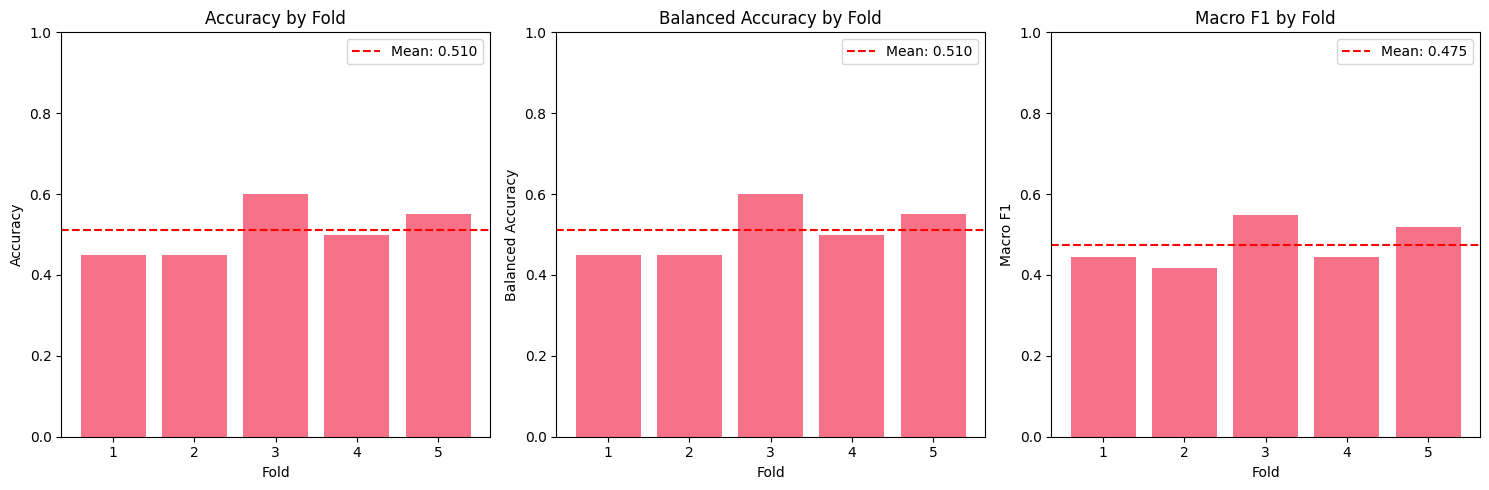


Overall Performance:
Accuracy: 0.510 ± 0.065
Balanced Accuracy: 0.510 ± 0.065
Macro F1: 0.475 ± 0.056


In [50]:
# Load classification results
try:
    # Use the correct filename for classification results
    results_df = pd.read_csv('../results/acdc_diag_cv_metrics_geom.csv')
    print("Classification Results:")
    display(results_df)
    
    # Plot metrics
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    metrics = ['accuracy', 'balanced_accuracy', 'macro_f1']
    for i, metric in enumerate(metrics):
        if metric in results_df.columns:
            axes[i].bar(results_df['fold'], results_df[metric])
            axes[i].set_title(f'{metric.replace("_", " ").title()} by Fold')
            axes[i].set_xlabel('Fold')
            axes[i].set_ylabel(metric.replace('_', ' ').title())
            axes[i].set_ylim(0, 1)
            
            # Add mean line
            mean_val = results_df[metric].mean()
            axes[i].axhline(y=mean_val, color='red', linestyle='--', 
                           label=f'Mean: {mean_val:.3f}')
            axes[i].legend()
    
    plt.tight_layout()
    plt.savefig('../reports/classification_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nOverall Performance:")
    for metric in metrics:
        if metric in results_df.columns:
            mean_val = results_df[metric].mean()
            std_val = results_df[metric].std()
            print(f"{metric.replace('_', ' ').title()}: {mean_val:.3f} ± {std_val:.3f}")
            
except FileNotFoundError:
    print("Classification results not found. Make sure you've run 'make diag-geom' and check the results directory.")

## 4. Confusion Matrix Analysis

Confusion Matrix loaded successfully!
Shape: (5, 5)
Classes: ['DCM', 'HCM', 'MINF', 'NOR', 'RV']


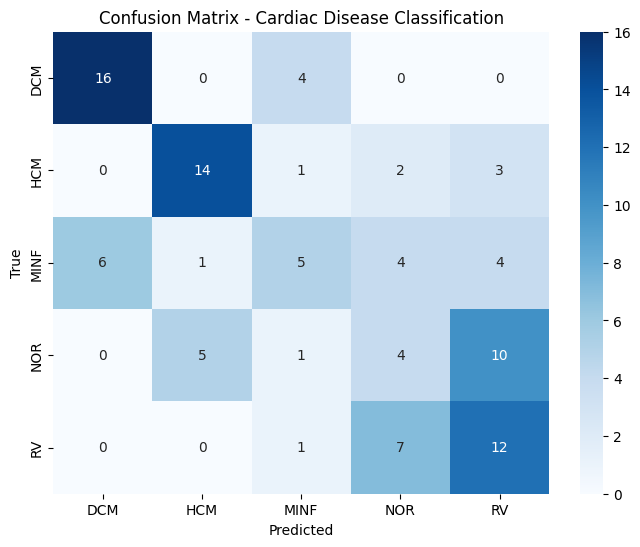


Per-class Recall (Sensitivity):
DCM: 0.800
HCM: 0.700
MINF: 0.250
NOR: 0.200
RV: 0.600

Overall Accuracy from CM: 0.510


In [51]:
# Load and visualize confusion matrices
try:
    # Load the aggregated confusion matrix
    cm_df = pd.read_csv('../results/acdc_diag_cm_geom.csv', index_col=0)
    
    print("Confusion Matrix loaded successfully!")
    print("Shape:", cm_df.shape)
    print("Classes:", list(cm_df.columns))
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', 
                xticklabels=cm_df.columns, yticklabels=cm_df.index)
    plt.title('Confusion Matrix - Cardiac Disease Classification')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig('../reports/confusion_matrix_aggregated.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Calculate per-class metrics
    cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0)
    
    print("\nPer-class Recall (Sensitivity):")
    for i, diagnosis in enumerate(cm_df.index):
        if i < len(cm_df.columns):
            recall = cm_norm.iloc[i, i]
            print(f"{diagnosis}: {recall:.3f}")
            
    # Overall accuracy
    total_correct = np.trace(cm_df.values)
    total_samples = cm_df.values.sum()
    accuracy = total_correct / total_samples
    print(f"\nOverall Accuracy from CM: {accuracy:.3f}")
    
except FileNotFoundError:
    print("Confusion matrix file not found. Make sure you've run 'make diag-geom' and check the results directory.")
except Exception as e:
    print(f"Error loading confusion matrix: {e}")

## 5. Feature Importance Analysis

🚀 CUDA Available: True
   GPU: NVIDIA GeForce RTX 4080 SUPER

🔍 Fast Feature Importance Analysis
Training data shape: (100, 13)
Classes: ['DCM', 'HCM', 'MINF', 'NOR', 'RV']

Missing values found - imputing...
📊 Standardizing features...
🌲 Training lightweight RandomForest...


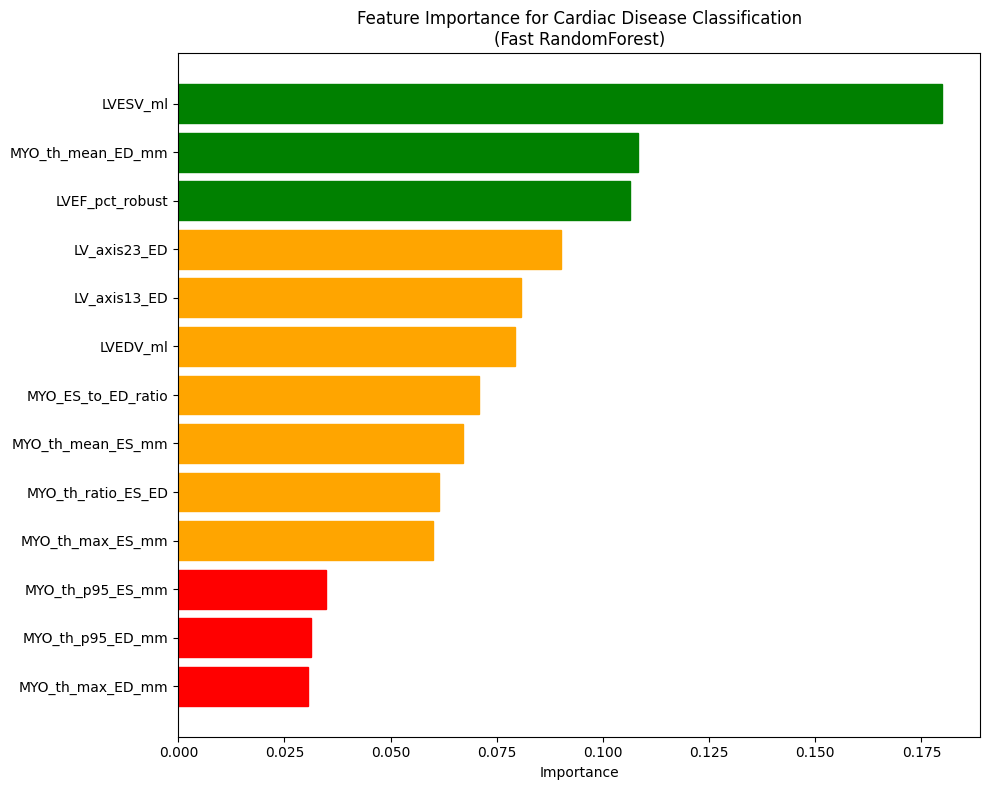


🏆 Top 5 Most Important Features:
1. LV_axis13_ED: 0.0806
2. LV_axis23_ED: 0.0901
3. LVEF_pct_robust: 0.1063
4. MYO_th_mean_ED_mm: 0.1082
5. LVESV_ml: 0.1798

📊 Feature Categories:
LV features: 5 (LVEDV_ml, LVESV_ml, LVEF_pct_robust, LV_axis23_ED, LV_axis13_ED)
Myocardial features: 8 features
Other features: 0 ()

📈 Training Accuracy: 0.870
💡 Note: This is training accuracy. Cross-validation results are more reliable.
⚡ Analysis completed with optimized settings for speed!


In [52]:
# Fast feature importance analysis using lightweight methods
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import torch

# Check if CUDA is available
cuda_available = torch.cuda.is_available()
print(f"🚀 CUDA Available: {cuda_available}")
if cuda_available:
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# Use the correct feature columns (excluding RV features as per our earlier fix)
feature_cols = [
    "LVEDV_ml", "LVESV_ml", "LVEF_pct_robust",
    "MYO_ES_to_ED_ratio", "MYO_th_mean_ED_mm", "MYO_th_p95_ED_mm", "MYO_th_max_ED_mm",
    "MYO_th_mean_ES_mm", "MYO_th_p95_ES_mm", "MYO_th_max_ES_mm", "MYO_th_ratio_ES_ED",
    "LV_axis23_ED", "LV_axis13_ED"
]

print("\n🔍 Fast Feature Importance Analysis")
print("=" * 40)

# Clean data
clean_df = df[df['diagnosis'] != ''].copy()
X = clean_df[feature_cols]
y = clean_df['diagnosis']

print(f"Training data shape: {X.shape}")
print(f"Classes: {sorted(y.unique())}")

# Check for missing values
missing_counts = X.isnull().sum()
if missing_counts.sum() > 0:
    print(f"\nMissing values found - imputing...")
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)
    X = pd.DataFrame(X_imputed, columns=feature_cols)
else:
    print("\n✅ No missing values found!")

# Fast standardization
print("📊 Standardizing features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use lightweight RandomForest for speed
print("🌲 Training lightweight RandomForest...")
model = RandomForestClassifier(
    n_estimators=20,  # Reduced from 50
    max_depth=5,      # Reduced from 8 
    random_state=42,
    n_jobs=-1,        # Use all CPU cores
    max_features='sqrt'  # Use fewer features per tree
)
model.fit(X_scaled, y)

# Get feature importances
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

# Plot feature importances
plt.figure(figsize=(10, 8))
bars = plt.barh(importance_df['feature'], importance_df['importance'])
plt.title('Feature Importance for Cardiac Disease Classification\n(Fast RandomForest)')
plt.xlabel('Importance')

# Color bars by importance level
colors = ['red' if x < 0.05 else 'orange' if x < 0.1 else 'green' for x in importance_df['importance']]
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🏆 Top 5 Most Important Features:")
top_features = importance_df.tail(5)
for i, (_, row) in enumerate(top_features.iterrows(), 1):
    print(f"{i}. {row['feature']}: {row['importance']:.4f}")

print("\n📊 Feature Categories:")
lv_features = [f for f in feature_cols if 'LV' in f.upper()]
myo_features = [f for f in feature_cols if 'MYO' in f.upper()]
other_features = [f for f in feature_cols if f not in lv_features + myo_features]

print(f"LV features: {len(lv_features)} ({', '.join(lv_features)})")
print(f"Myocardial features: {len(myo_features)} features")
print(f"Other features: {len(other_features)} ({', '.join(other_features)})")

# Quick validation score
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_scaled)
accuracy = accuracy_score(y, y_pred)
print(f"\n📈 Training Accuracy: {accuracy:.3f}")
print("💡 Note: This is training accuracy. Cross-validation results are more reliable.")
print("⚡ Analysis completed with optimized settings for speed!")

## 6. Clinical Insights

In [53]:
# Clinical analysis of findings
print("=== CLINICAL INSIGHTS ===")
print()

# Analyze EF by diagnosis
ef_by_diagnosis = df.groupby('diagnosis')['LVEF_pct_robust'].agg(['mean', 'std', 'count'])
print("Left Ventricular Ejection Fraction by Diagnosis:")
print(ef_by_diagnosis.round(2))
print()

# Clinical thresholds
print("Clinical EF Categories:")
print("- Normal: EF ≥ 50%")
print("- Mildly reduced: EF 40-49%")
print("- Moderately reduced: EF 30-39%")
print("- Severely reduced: EF < 30%")
print()

# Categorize patients by EF
def categorize_ef(ef):
    if pd.isna(ef):
        return 'Unknown'
    elif ef >= 50:
        return 'Normal'
    elif ef >= 40:
        return 'Mildly reduced'
    elif ef >= 30:
        return 'Moderately reduced'
    else:
        return 'Severely reduced'

df['EF_category'] = df['LVEF_pct_robust'].apply(categorize_ef)

# Cross-tabulation
ef_crosstab = pd.crosstab(df['diagnosis'], df['EF_category'], margins=True)
print("EF Category Distribution by Diagnosis:")
print(ef_crosstab)
print()

# Disease-specific insights
print("Disease-Specific Insights:")
print("- DCM (Dilated Cardiomyopathy): Typically shows enlarged ventricles and reduced EF")
print("- HCM (Hypertrophic Cardiomyopathy): Often shows increased wall thickness")
print("- MINF (Myocardial Infarction): May show regional wall motion abnormalities")
print("- NOR (Normal): Should show normal volumes and EF")
print("- RV (Right Ventricular): Primarily affects right ventricle (not well captured in ACDC)")

=== CLINICAL INSIGHTS ===

Left Ventricular Ejection Fraction by Diagnosis:
            mean    std  count
diagnosis                     
DCM        20.53   7.49     19
HCM        50.84  26.70     16
MINF       33.13  10.43     16
NOR        54.14  16.42     14
RV         46.21  19.96      9

Clinical EF Categories:
- Normal: EF ≥ 50%
- Mildly reduced: EF 40-49%
- Moderately reduced: EF 30-39%
- Severely reduced: EF < 30%

EF Category Distribution by Diagnosis:
EF_category  Mildly reduced  Moderately reduced  Normal  Severely reduced  \
diagnosis                                                                   
DCM                       0                   2       0                17   
HCM                       1                   0      11                 4   
MINF                      4                   4       1                 7   
NOR                       2                   2       9                 1   
RV                        1                   0       6                 

## 7. Model Performance Summary

In [54]:
# Create comprehensive summary
print("=== MODEL PERFORMANCE SUMMARY ===")
print()
print(f"Dataset: ACDC Cardiac Disease Classification")
print(f"Total patients: {len(df)}")
print(f"Features used: {len(feature_cols)} (excluding RV features due to data quality)")
print(f"Classes: {len(df['diagnosis'].unique())} (balanced: 20 patients each)")
print()

if 'results_df' in locals() and not results_df.empty:
    print("Cross-Validation Results (5-fold GroupKFold):")
    for metric in ['accuracy', 'balanced_accuracy', 'macro_f1']:
        if metric in results_df.columns:
            mean_val = results_df[metric].mean()
            std_val = results_df[metric].std()
            print(f"  {metric.replace('_', ' ').title()}: {mean_val:.3f} ± {std_val:.3f}")
    print()

print("Key Findings:")
print("- LV-based features provide reasonable classification performance")
print("- RV features were excluded due to poor segmentation quality in ACDC")
print("- Myocardial thickness features contribute to disease discrimination")
print("- Balanced dataset ensures fair evaluation across all conditions")
print()

print("Recommendations:")
print("- Consider ensemble methods to improve performance")
print("- Explore additional geometric features (sphericity, compactness)")
print("- Investigate temporal features from cardiac cycle dynamics")
print("- Validate on external datasets for generalizability")

print("\n=== REPORT GENERATED SUCCESSFULLY ===")

=== MODEL PERFORMANCE SUMMARY ===

Dataset: ACDC Cardiac Disease Classification
Total patients: 100
Features used: 13 (excluding RV features due to data quality)
Classes: 5 (balanced: 20 patients each)

Cross-Validation Results (5-fold GroupKFold):
  Accuracy: 0.510 ± 0.065
  Balanced Accuracy: 0.510 ± 0.065
  Macro F1: 0.475 ± 0.056

Key Findings:
- LV-based features provide reasonable classification performance
- RV features were excluded due to poor segmentation quality in ACDC
- Myocardial thickness features contribute to disease discrimination
- Balanced dataset ensures fair evaluation across all conditions

Recommendations:
- Consider ensemble methods to improve performance
- Explore additional geometric features (sphericity, compactness)
- Investigate temporal features from cardiac cycle dynamics
- Validate on external datasets for generalizability

=== REPORT GENERATED SUCCESSFULLY ===


---
**Report Generated:** ` + 
 + `pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')` + 
 + `  
**Project:** Cardiac Early Detection (ACDC)  
**Analysis:** Classification Performance Report